In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

import warnings
warnings.filterwarnings("ignore")

This notebook performs exploratory data analysis (EDA) on news headlines to understand textual patterns, publisher activity, and time-based trends.

The goal is to identify:
- Patterns in headline structure
- Most active news publishers
- Common keywords and themes in financial news
- Time-based spikes in news publication
# 📂 Load Dataset

We load the financial news dataset and inspect its structure.

In [5]:
df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")  # adjust path if needed
df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


# 📊 1. Descriptive Statistics

We analyze headline structure, publisher distribution, and dataset overview.

In [6]:
df.info()

df = df.drop_duplicates()

df["headline"] = df["headline"].astype(str)
df["date"] = pd.to_datetime(df["date"], errors="coerce")

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB


In [7]:
df["headline_length"] = df["headline"].apply(len)

df["headline_length"].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

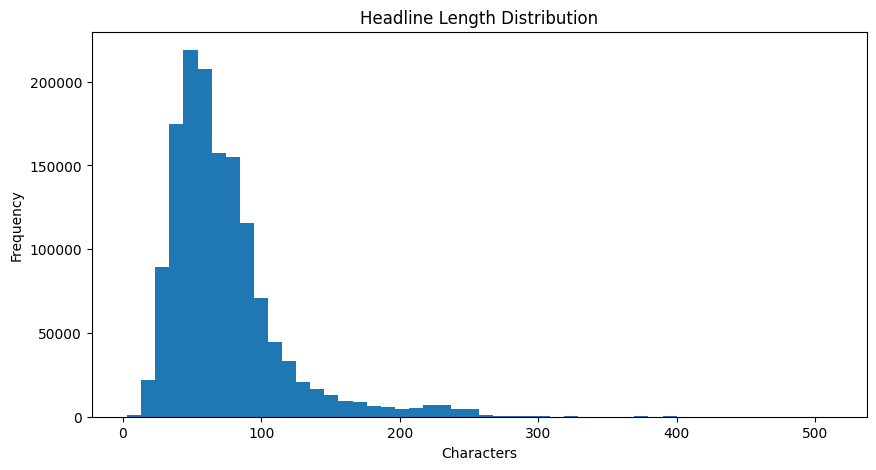

In [8]:
plt.figure(figsize=(10,5))
plt.hist(df["headline_length"], bins=50)
plt.title("Headline Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

In [9]:
publisher_counts = df["publisher"].value_counts()
publisher_counts.head(10)

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

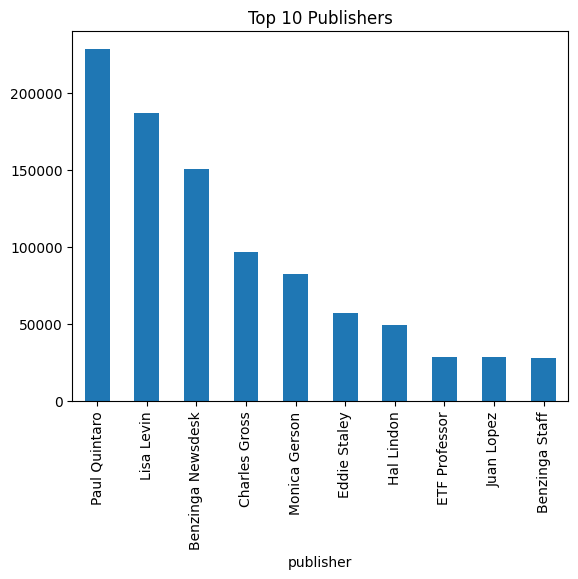

In [10]:
plt.figure()
publisher_counts.head(10).plot(kind='bar')
plt.title("Top 10 Publishers")
plt.show()

# ⏱️ 2. Time Series Analysis

We analyze news publication trends over time and detect spikes in activity.

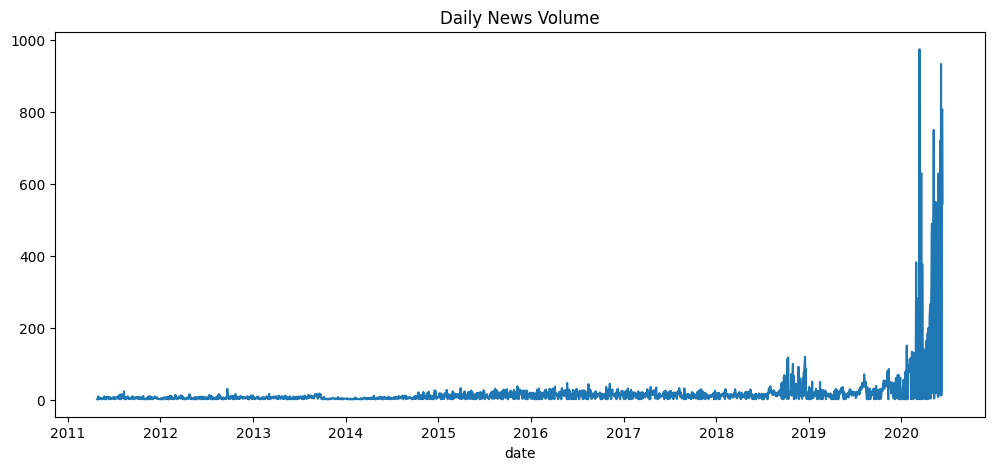

In [11]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

daily_news = df.groupby(df['date'].dt.date).size()

daily_news.plot(figsize=(12,5))
plt.title("Daily News Volume")
plt.show()

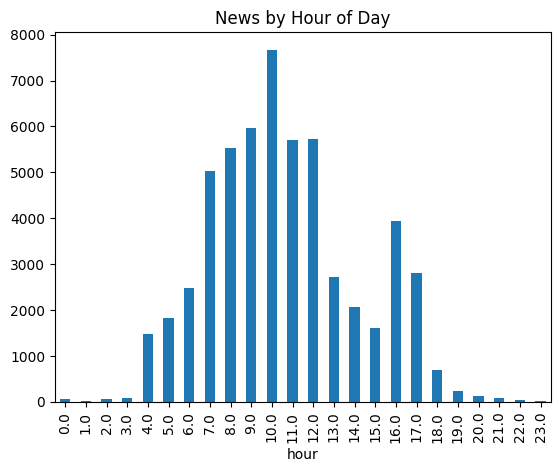

In [ ]:
df['hour'] = df['date'].dt.hour

df['hour'].value_counts().sort_index().plot(kind='bar')
plt.title("News by Hour of Day")
plt.show()

In [ ]:
df['hour'] = df['date'].dt.hour

df['hour'].value_counts().sort_index().plot(kind='bar')
plt.title("News by Hour of Day")
plt.show()

# 🧠 3. Text Analysis (NLP)

We extract important keywords using TF-IDF to identify key financial topics.

In [13]:
tfidf = TfidfVectorizer(stop_words='english', max_features=1000)

X = tfidf.fit_transform(df['headline'].astype(str))

In [14]:
feature_names = tfidf.get_feature_names_out()

sum_words = X.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in tfidf.vocabulary_.items()]

words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

words_freq[:10]

[('stocks', np.float64(42975.287281360295)),
 ('market', np.float64(33184.13039362711)),
 ('vs', np.float64(31418.860586868097)),
 ('benzinga', np.float64(29693.023010753714)),
 ('est', np.float64(28731.552099963916)),
 ('earnings', np.float64(27551.88663820875)),
 ('reports', np.float64(25784.133631533867)),
 ('eps', np.float64(25517.447654509815)),
 ('shares', np.float64(24976.320752790078)),
 ('update', np.float64(24284.873804641877))]

# 🏢 4. Publisher Analysis

We analyze which publishers contribute the most news articles and detect possible domain patterns.

In [16]:
df['publisher'].value_counts().head(20)

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Allie Wickman         18317
Shanthi Rexaline      16640
Craig Jones           16221
Wayne Duggan          12897
Nelson Hem            12590
Name: count, dtype: int64

In [17]:
df['domain'] = df['publisher'].str.extract(r'@([\w\.-]+)')
df['domain'].value_counts().head(10)

domain
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64

# 📌 Key Insights

From this analysis, we aim to identify:

- Most active publishers
- News volume spikes over time
- Peak publishing hours
- Dominant financial keywords and themes